# Description

- Bayesian networks for probabilistic inference with pgmpy:
  - Building networks and defining conditional relationships
  - Conditional probability tables (CPDs)
  - Exact and approximate inference algorithms
  - MAP queries and interactive visualizations

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

# System libraries.
import logging

# Third-party libraries.
import matplotlib.pyplot as plt

In [2]:
# # To install additional packages, use:
# import helpers.hmodule as hmodule
# hmodule.install_module_if_not_present(
#     ["pgmpy"],
#     use_activate=True,
#     use_sudo=False,
#     venv_path="/opt/venv",
# )

In [3]:
# Use this for most notebooks.
import helpers.hdbg as hdbg
import helpers.hnotebook as hnotebook

_LOG = logging.getLogger(__name__)

# Initialize notebook configuration and logging.
# hnotebook.config_notebook()
# hdbg.init_logger(verbosity=logging.INFO, use_exec_path=False)
# hnotebook.set_logger_to_print(_LOG)

import probabilistic_inference_utils as utils

# Convert `display` into `print()`.
try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore

import warnings

warnings.filterwarnings("ignore")

/opt/venv/lib/python3.12/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


- **Definition**: Bayesian networks are directed acyclic graphs encoding conditional relationships
  - Nodes represent random variables
  - Edges represent conditional dependencies
  - Structure encodes independence assumptions

- **Medical diagnosis example**: Infer disease status from observable symptoms and test results
  - Disease: Hidden cause we want to infer
  - Symptom: Observable sign depending on disease status
  - Test: Diagnostic test result depending on disease status

- **Key insight**: Given disease status, symptom and test are conditionally independent
  - Enables efficient inference algorithms
  - Order of evidence doesn't matter for combining observations

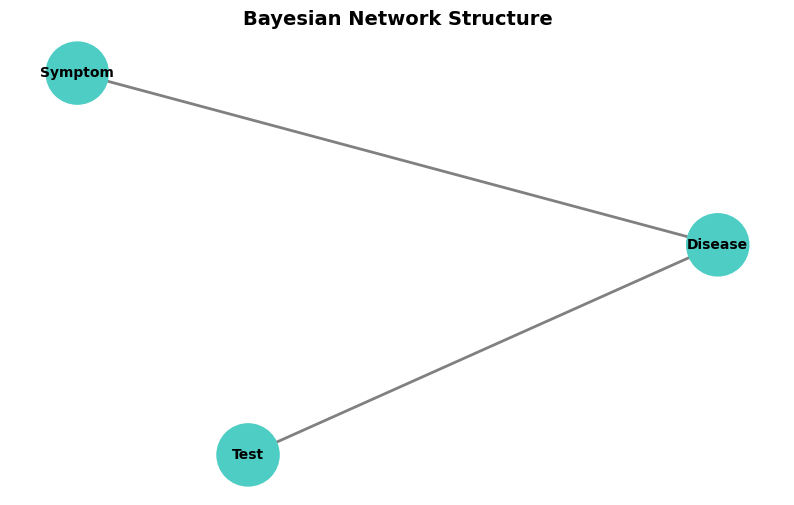

Network structure encodes independence:
Given Disease, Symptom and Test are independent of each other.

This is critical for efficient inference!


In [4]:
# Build the medical diagnosis network
model = utils.create_medical_network()

# Visualize the network structure
utils.visualize_network(model)
plt.show()

print("Network structure encodes independence:")
print("Given Disease, Symptom and Test are independent of each other.")
print("\nThis is critical for efficient inference!")

- **CPD**: Conditional probability table assigns numerical beliefs to network structure
  - Root nodes (no parents): Prior probability distribution
  - Non-root nodes: Conditional probability given parent values

- **Medical domain knowledge encoded in CPDs**:
  - Disease prevalence in population
  - Symptom likelihood given disease status
  - Diagnostic test accuracy

- **Key concept**: CPDs + network structure = complete probabilistic model
  - Enables queries about unobserved variables given evidence

In [ ]:
# Interactive CPD visualization
utils.create_cpd_widget(disease_prior=0.05)

- **Forward sampling**: Draw samples from prior distribution before observing any data
  - Each sample: one hypothetical patient
  - Samples reflect network beliefs

- **Observation**: Rare diseases stay rare in samples even when they cause symptoms
  - Base rate (disease prevalence) dominates the samples
  - Disease prior: 5% means most samples show disease absent

In [ ]:
# Sample from the prior distribution
model = utils.create_medical_network()
utils.forward_sample_and_plot(model, n_samples=1000)
plt.show()

print("This is what the network believes in a vacuum.")
print("Disease is rare (5%), so both Symptom and Test mostly indicate Absent.")

- **Variable Elimination**: Exact inference algorithm computes probabilities without sampling
  - Guaranteed correct
  - Scales poorly with network size
  - Fast for small networks (like ours)

- **Comparison**: Exact inference vs forward sampling
  - Exact results (blue) match forward samples (orange) perfectly
  - Both answer: "What do we believe (prior)?"
  - Sampling becomes more accurate with more samples

In [ ]:
# Compare exact inference with forward sampling
model = utils.create_medical_network()
utils.compare_exact_and_sampling(model)
plt.show()

print("Exact Inference: Variable Elimination")
print("- Guaranteed correct")
print("- Scales poorly with network size")
print("- Fast for small networks")
print("\nForward Sampling: Approximate")
print("- Gets more accurate with more samples")
print("- Scales to large networks")
print("- Slower per query but parallelizable")

- **Core inference concept**: Observing evidence shifts what we believe about unobserved variables
  - Prior: Disease probability = 5%
  - Positive test: Disease probability = ~45%
  - Negative test: Disease probability = <1%

- **Strength of shift depends on evidence informativeness**:
  - Test accuracy: 95% for positives, 90% for negatives
  - Fairly informative about disease status

- **Bayes' rule in action**: $\Pr(\text{Disease} | \text{Evidence}) = \frac{\Pr(\text{Evidence} | \text{Disease}) \Pr(\text{Disease})}{\Pr(\text{Evidence})}$
  - Prior beliefs updated using observed evidence

In [ ]:
# Show effect of conditioning on evidence
model = utils.create_medical_network()
utils.condition_on_evidence(model)
plt.show()

print("This is Bayes' rule in action:")
print("P(Disease | Evidence) = P(Evidence | Disease) * P(Disease) / P(Evidence)")
print("\nWe update prior beliefs using observed evidence.")

- **Interactive exploration**: Combine different evidence and observe posterior probability updates in real time

- **Try these combinations**:
  - Positive test alone
  - Positive test + symptom present (strong evidence)
  - Positive test + symptom absent (conflicting evidence)

- **Network behavior**: Combines evidence probabilistically
  - Order of evidence doesn't matter
  - Encodes probability, not causality in time

In [ ]:
# Interactive evidence explorer
model = utils.create_medical_network()
utils.create_evidence_explorer()

- **Inference algorithms**: Different approaches with different performance tradeoffs

- **Exact methods**:
  - Variable Elimination: Efficient for small networks
  - Belief Propagation: Efficient for tree-structured networks

- **Approximate methods**:
  - Sampling: Scales to large networks, requires more samples for accuracy

- **Small networks**: All methods give identical results
  - Choice of algorithm driven by network size and structure

In [ ]:
# Compare inference algorithms
model = utils.create_medical_network()
utils.compare_inference_algorithms()
plt.show()

print("All methods answer the same question correctly.")
print("Choice of algorithm is driven by network size and structure.")
print("\nRule of thumb:")
print("- <=15 variables: Exact methods (Variable Elimination)")
print("- >15 variables: Approximate methods (Sampling, Variational)")

- **Gibbs sampling**: Markov Chain Monte Carlo algorithm generating samples from posterior distribution

- **Key parameters**:
  - Burn-in: Early samples depend on initialization, discard them
  - Sample count: More samples = more accuracy, slower computation

- **Convergence**: With enough samples, empirical frequencies match true probabilities
  - Trade-off: accuracy vs computational cost

In [ ]:
# Gibbs sampling interactive visualization
model = utils.create_medical_network()
utils.gibbs_sampling_interactive()

- **Real inference problems**: Multiple observed variables with joint distribution over unobserved variables
  - Full joint contains more information than individual marginals
  - Different observation combinations reveal different dependencies

- **Explore combinations**:
  - Disease alone
  - Disease + Symptom
  - Disease + Test

- **Visualization**: Heatmap shows joint probability distribution
  - Marginal bar plots show what we learn about individual variables

In [ ]:
# Joint distribution explorer
model = utils.create_medical_network()
utils.joint_distribution_explorer()

- **MAP query**: Find single most likely explanation for evidence

- **Distinction from marginal inference**:
  - Marginal: $\Pr(\text{Disease} = \text{Yes} | \text{Evidence})$ for individual variables
  - MAP: $\arg\max \Pr(\text{Disease}, \text{Symptom} | \text{Evidence})$ single joint assignment

- **Practical use**: Diagnostics want single best explanation
  - "What's most likely disease state and symptom combination?"

In [ ]:
# MAP query demonstration
model = utils.create_medical_network()
utils.map_query_demo()
plt.show()

print("MAP finds the single most likely joint assignment.")
print("Useful for diagnosis: 'What's the best explanation for the observations?'")

- **Real-world networks**: Many variables: genetic factors, lifestyle, multiple tests, symptoms, environmental factors

- **Computational challenges at scale**:
  - Exact inference becomes intractable (exponential in variables)
  - Network topology (tree vs loopy) matters for algorithm efficiency
  - Must choose algorithm carefully based on problem size

- **Scaling rules of thumb**:
  - Up to 15 variables: Exact methods (Variable Elimination)
  - Beyond 15: Approximate methods (Sampling, Variational)

In [ ]:
# Larger network interactive demo
utils.larger_network_interactive()

- **Practical workflow**: From model to inference and interpretation

- **Steps**:
  1. Load pre-trained or pre-built Bayesian network
  2. Inspect model structure and probability tables
  3. Validate CPDs are well-formed (sum to 1)
  4. Choose inference algorithm based on network size
  5. Query with evidence to answer domain questions
  6. Interpret results in context

In [ ]:
# Practical workflow demonstration
model = utils.larger_network_demo()
utils.practical_workflow_demo()

- **Structure**: Bayesian networks encode conditional relationships and independence assumptions

- **Probabilities**: CPDs assign numerical beliefs to network structure

- **Inference**: Computing $\Pr(\text{unobserved} | \text{observed})$ using Bayes' rule

- **Algorithms**: Different exact/approximate methods with different tradeoffs
  - Exact methods for small networks
  - Approximate methods for large networks

- **Key insights**:
  - Same network + different evidence = different conclusions
  - Algorithm choice depends on network size
  - Order of evidence doesn't matter

- **Next steps**:
  - Build networks for your domain
  - Compare MAP and marginal inference
  - Learn parameter learning (fitting CPDs from data)
  - Explore structure learning (discovering network structure from data)